# Figure S1: Nutrient Uptake Curve Fitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import sys
import os
# Add the directory containing model_utils.py to the Python path
sys.path.append('../models')
from pi_npz import PhysicsInformedNN, DNN, forward_pinn
from traditional_npz import rk4, npz_nl, run_rk4_for_initial_conditions
sys.path.append('../utils')
from additional_files import embedded_npz, calculate_rel_error, calculate_rmse

# RK4 for a single set of initial conditions
def run_rk4_embedded_npz(N0, P0, Z0, t, phi):
    # Define the initial conditions as a list
    x0 = [N0, P0, Z0]
    # Use the rk4 method to expand the system over time
    xt = rk4(embedded_npz, x0, t, None, 0, phi)
    return xt
    

In [2]:
# Define the parameters for the system
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

# Define the time parameters
tstart = 0  # Start time (day 0)
tend = 7 # End time (day 7)
minutes_per_step = 10  # Time step in minutes
minutes_per_hour = 60  # Constant time per hour
hours_per_day = 24  # Constant time per day
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
t = np.arange(tstart, tend + dt, dt)  # Create the array of times

N0 = 1.6
P0 = 0.3
Z0 = 0.1

# Run RK4 with these initial conditions
original_npz = run_rk4_for_initial_conditions(N0, P0, Z0, t, phi)


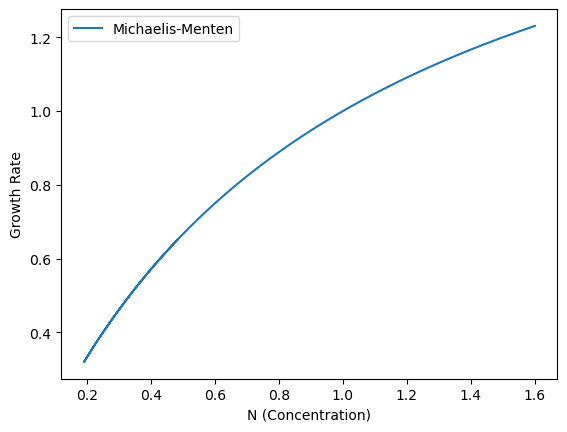

In [3]:
# Parameters for the Michaelis-Menten equation
Vm = 2.0  # Maximum growth rate
ks = 1.0  # Half-Saturation constant for nitrate

N_orig = original_npz[:, 0]

# Define the Michaelis-Menten function
def michaelis_menten(N, Vm, ks):
    return Vm * N / (ks + N)

MM_values = michaelis_menten(N_orig, Vm, ks)

# Plot the Michaelis-Menten function
plt.plot(N_orig, MM_values, label='Michaelis-Menten')
plt.xlabel('N (Concentration)')
plt.ylabel('Growth Rate')
plt.legend()
plt.show()


Uptake parameter α: 1.2166
Uptake parameter β: 1.2791


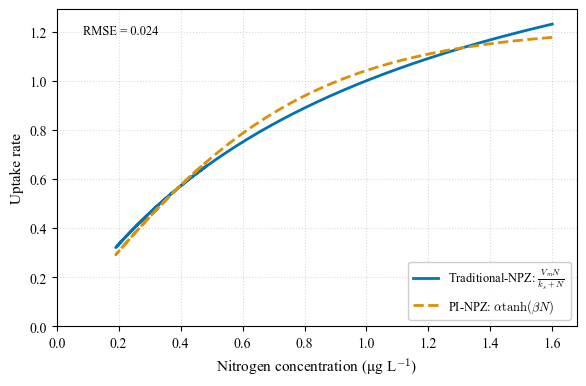

In [6]:
# Typography for JAMES publication (matching your forecast figure)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11  # Base font size for consistency

# Colorblind-friendly color scheme
# Using colors from Wong (2011) Nature Methods colorblind-safe palette
mm_color = "#0173B2"      # Blue for Michaelis-Menten
tanh_color = "#DE8F05"    # Orange for Tanh approximation

from scipy.optimize import curve_fit
np.random.seed(1234)

# Using hyperbolic tangent to approximate Michaelis-Menten (MM) dynamics
def tanh_approx(N, a, b):
    return a * np.tanh(b * N)

# Initial guess for the parameters
initial_guess = [Vm, ks]

# Fit the tanh function to the Michaelis-Menten data
mm_params, _ = curve_fit(tanh_approx, N_orig, MM_values, p0=initial_guess)

# Extract optimized parameters
a, b = mm_params
print(f"Uptake parameter α: {a:.4f}")
print(f"Uptake parameter β: {b:.4f}")

# Calculate the tanh approximation values
tanh_values = tanh_approx(N_orig, a, b)

# === Create publication-quality figure ===
fig, ax = plt.subplots(figsize=(6, 4))  # Smaller size for supplementary figure

# Plot both curves with colorblind-friendly colors
ax.plot(N_orig, MM_values, color=mm_color, linewidth=2, 
        label=r'Traditional-NPZ: $\frac{V_mN}{k_s+N}$')
ax.plot(N_orig, tanh_values, color=tanh_color, linewidth=2, 
        linestyle='--', label=r'PI-NPZ: $\alpha\tanh(\beta N)$')

# Labels with consistent formatting
ax.set_xlabel(r"Nitrogen concentration (μg L$^{-1}$)", fontsize=11)
ax.set_ylabel("Uptake rate", fontsize=11)

# Set reasonable axis limits
ax.set_xlim(0, N_orig.max() * 1.05)
ax.set_ylim(0, max(MM_values.max(), tanh_values.max()) * 1.05)

# Format axes
ax.tick_params(labelsize=10)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')

# Add legend with mathematical expressions
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

# Optional: Add RMSE as text annotation
rmse_tanh = np.sqrt(np.mean((MM_values - tanh_values) ** 2))
ax.text(0.05, 0.95, f'RMSE = {rmse_tanh:.3f}', 
        transform=ax.transAxes, fontsize=9, 
        verticalalignment='top')

plt.tight_layout()

# === Save ===
# base_path = "../figures/"
# file_base = f"nutrient_uptake_approximation"

# # Save as vector format (PDF) for publication and PNG for review
# for ext in ["pdf"]:
#     if ext == "png":
#         dpi = 600  # High DPI for raster
#     else:
#         dpi = None  # Vector formats don't need DPI
#     plt.savefig(f"{base_path}{file_base}.{ext}", 
#                 dpi=dpi, 
#                 bbox_inches='tight', 
#                 pad_inches=0.02,
#                 format=ext)

plt.show()
